# Hydrogen extraction with DARTS

In the tank model, the pressure was the same throughout the reservoir. Here I divide the rock into a three-dimensional grid and calculate flow between the cells. This is the first DARTS model, using a natural-gas depletion problem as the starting point.

I used hydrogen and water as two immiscible phases. A second run replaces hydrogen with methane, so that we can compare their pressure and production behavior under the same assumed conditions. A third run adds a specified hydrogen supply. The later Bourakébougou model adds dissolved hydrogen and gas mixtures.

## Import the packages and set the reservoir properties

Use the existing `darts-local` kernel. The model is stored in Python files so that the same calculation can be used from this notebook and from the terminal. All pressure inputs are absolute bar.

In [1]:
from pathlib import Path
import sys, json, contextlib, io
from IPython.display import display, Image
expected = Path('/Users/sanderbertdacosta/.local/share/python-envs/darts-py311/bin/python').resolve()
assert Path(sys.executable).resolve() == expected, 'Select the darts-local kernel.'
project = next((p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / 'white_hydrogen' / 'darts' / 'model.py').exists()), None)
assert project is not None, 'Open this notebook in the reservoir simulation project.'
if str(project) not in sys.path:
    sys.path.insert(0, str(project))
from white_hydrogen.darts.properties import load_config
from white_hydrogen.darts.run import run_suite
folder = project / 'white_hydrogen' / 'darts'
output = folder / 'output'
print('Python:', sys.executable)

Python: /Users/sanderbertdacosta/.local/share/python-envs/darts-py311/bin/python


In [2]:
parameters = {}  # Example: {'permeability_md': 5.0, 'runtime_days': 730.0}
config = load_config(parameters)
for name in ['nx', 'ny', 'nz', 'length_x_m', 'length_y_m', 'thickness_m',
             'depth_m', 'initial_pressure_bar', 'temperature_k', 'porosity',
             'permeability_md', 'initial_water_saturation', 'producer_bhp_bar']:
    print(name, config[name])

nx 21
ny 21
nz 5
length_x_m 1000.0
length_y_m 1000.0
thickness_m 30.0
depth_m 1000.0
initial_pressure_bar 100.0
temperature_k 330.0
porosity 0.15
permeability_md 10.0
initial_water_saturation 0.2
producer_bhp_bar 30.0


## Initial pressure and the production well

The initial pressure is specified at the middle depth of the reservoir. Gas pressure increases with depth according to its density. We calculate the gas mole fraction separately in each layer so that initial water saturation stays at 0.20. The water is initially at its immobile endpoint.

The well is completed through the reservoir layers. Its prescribed bottomhole pressure has the same depth reference as the initial pressure. The grid has 21 × 21 × 5 cells in the supplied case, with a total thickness of 30 m. These dimensions and flow properties describe an illustrative reservoir.

## Calculate depletion and replenishment

The mass balance is

$$M(t)=M_0+M_{\mathrm{supply}}(t)-M_{\mathrm{produced}}(t)-M_{\mathrm{loss}}(t).$$

The density calculation includes the corrected NIST hydrogen compressibility factor. Production follows Darcy flow and decreases as reservoir pressure declines. The methane run uses different gas properties but the same geometry and well pressure. We compare recovered fractions as well as masses, because the initial gas masses differ.

The external supply in the sensitivity is prescribed. It does not calculate chemical generation.

In [3]:
# Read the supplied completed runs, or set True after changing parameters.
rerun = False
cases = {'hydrogen': {}, 'methane': {'species': 'CH4', 'eos': 'peng_robinson'},
         'recharge': {'recharge_kg_day': 300.0}}
if rerun:
    with contextlib.redirect_stdout(io.StringIO()):
        summaries = run_suite(output, parameters)
else:
    summaries = {}
    for name, changes in cases.items():
        status = json.loads((output / name / 'status.json').read_text())
        assert status['status'] == 'complete', f'{name} has no completed run.'
        result = json.loads((output / name / 'summary.json').read_text())
        assert result['parameters'] == load_config(parameters | changes), 'Inputs changed: set rerun = True.'
        summaries[name] = result
    print('Reading completed native DARTS calculations.')
for name, result in summaries.items():
    print(f"{name:10s} {result['produced_gas_kg']/1e6:8.3f} million kg produced"
          f"  {result['final_pressure_mean_bar']:7.3f} bar mean pressure"
          f"  {100*result['produced_fraction_of_initial_inventory']:6.2f}% recovered")

Reading completed native DARTS calculations.
hydrogen     12.259 million kg produced   49.753 bar mean pressure   48.94% recovered
methane     108.095 million kg produced   56.848 bar mean pressure   45.51% recovered
recharge     12.313 million kg produced   49.976 bar mean pressure   49.15% recovered


## Pressure and production results

The gas-pressure difference drives production. Adding a specified supply changes both the remaining inventory and cumulative production. The balance plot compares independently integrated well fluxes with the change in native stored mass.

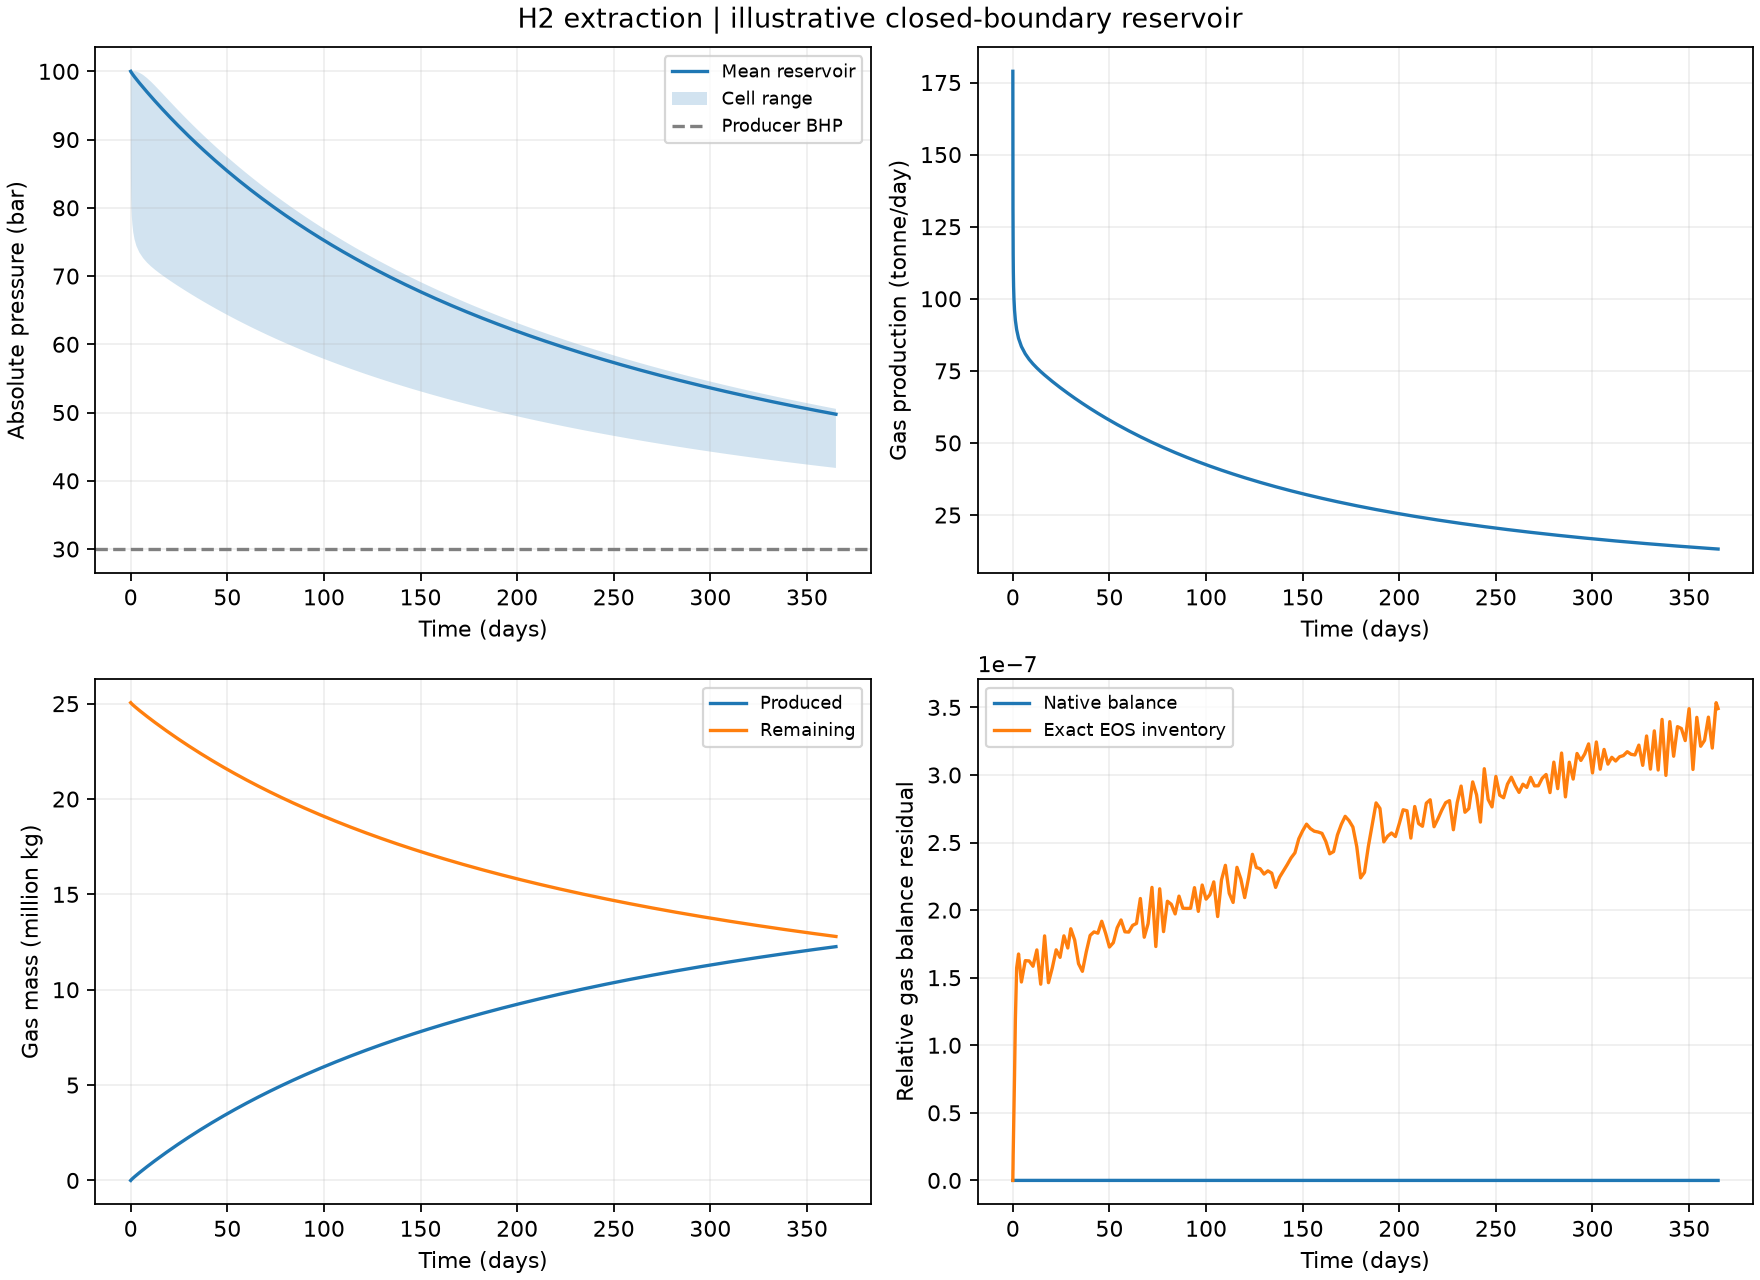

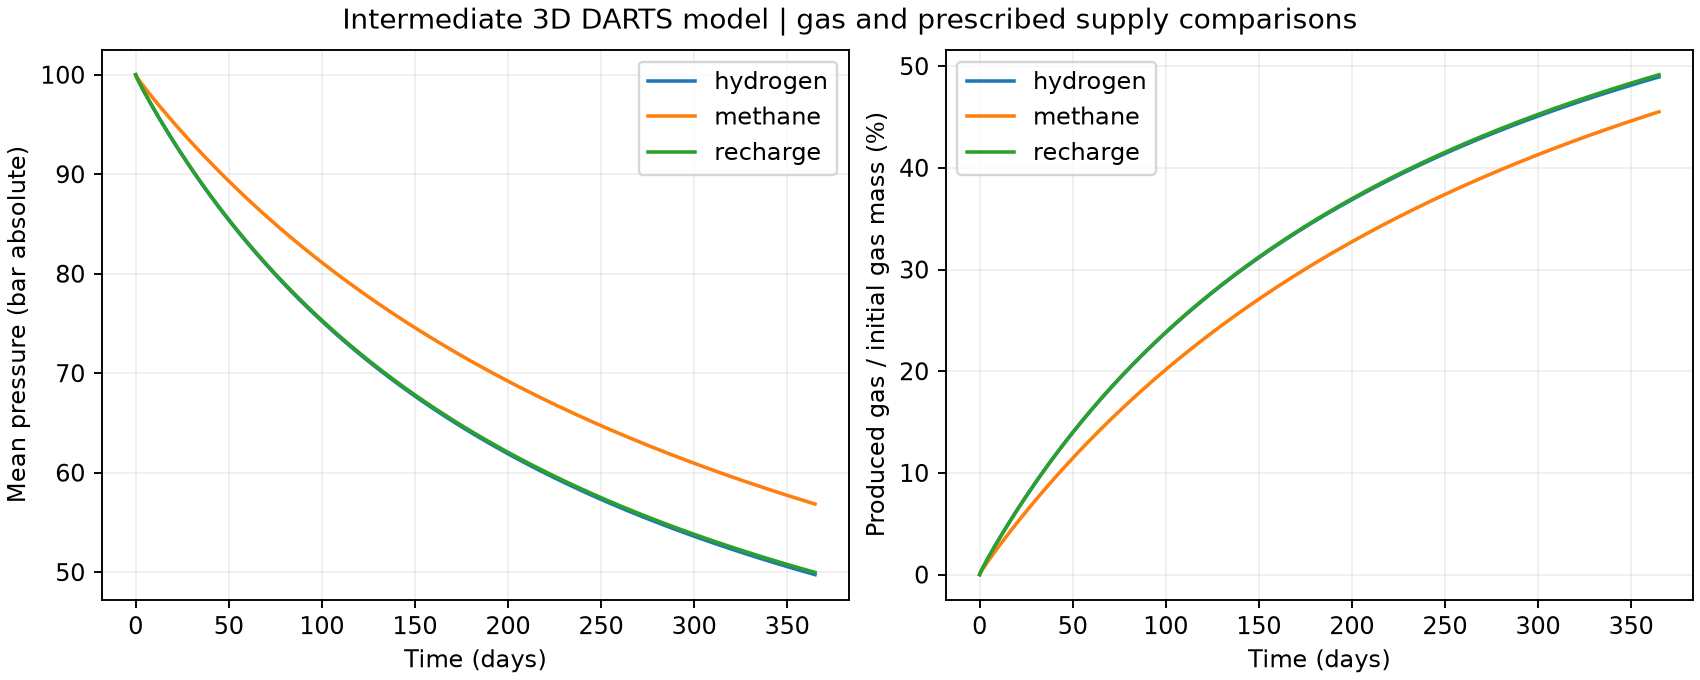

In [4]:
display(Image(filename=str(output / 'hydrogen' / 'production.png')))
display(Image(filename=str(output / 'scenario_comparison.png')))

## The reservoir in three dimensions

The 3D view shows actual calculated cell values on orthogonal slices. The vertical scale is expanded to make the five layers visible. The thick red line marks the completed well and the star marks the pressure datum. The second image shows the middle horizontal layer.

The initial and final `.vtk` files can be opened in a 3D scientific viewer. Cell snapshots and timestep histories are also saved as CSV files.

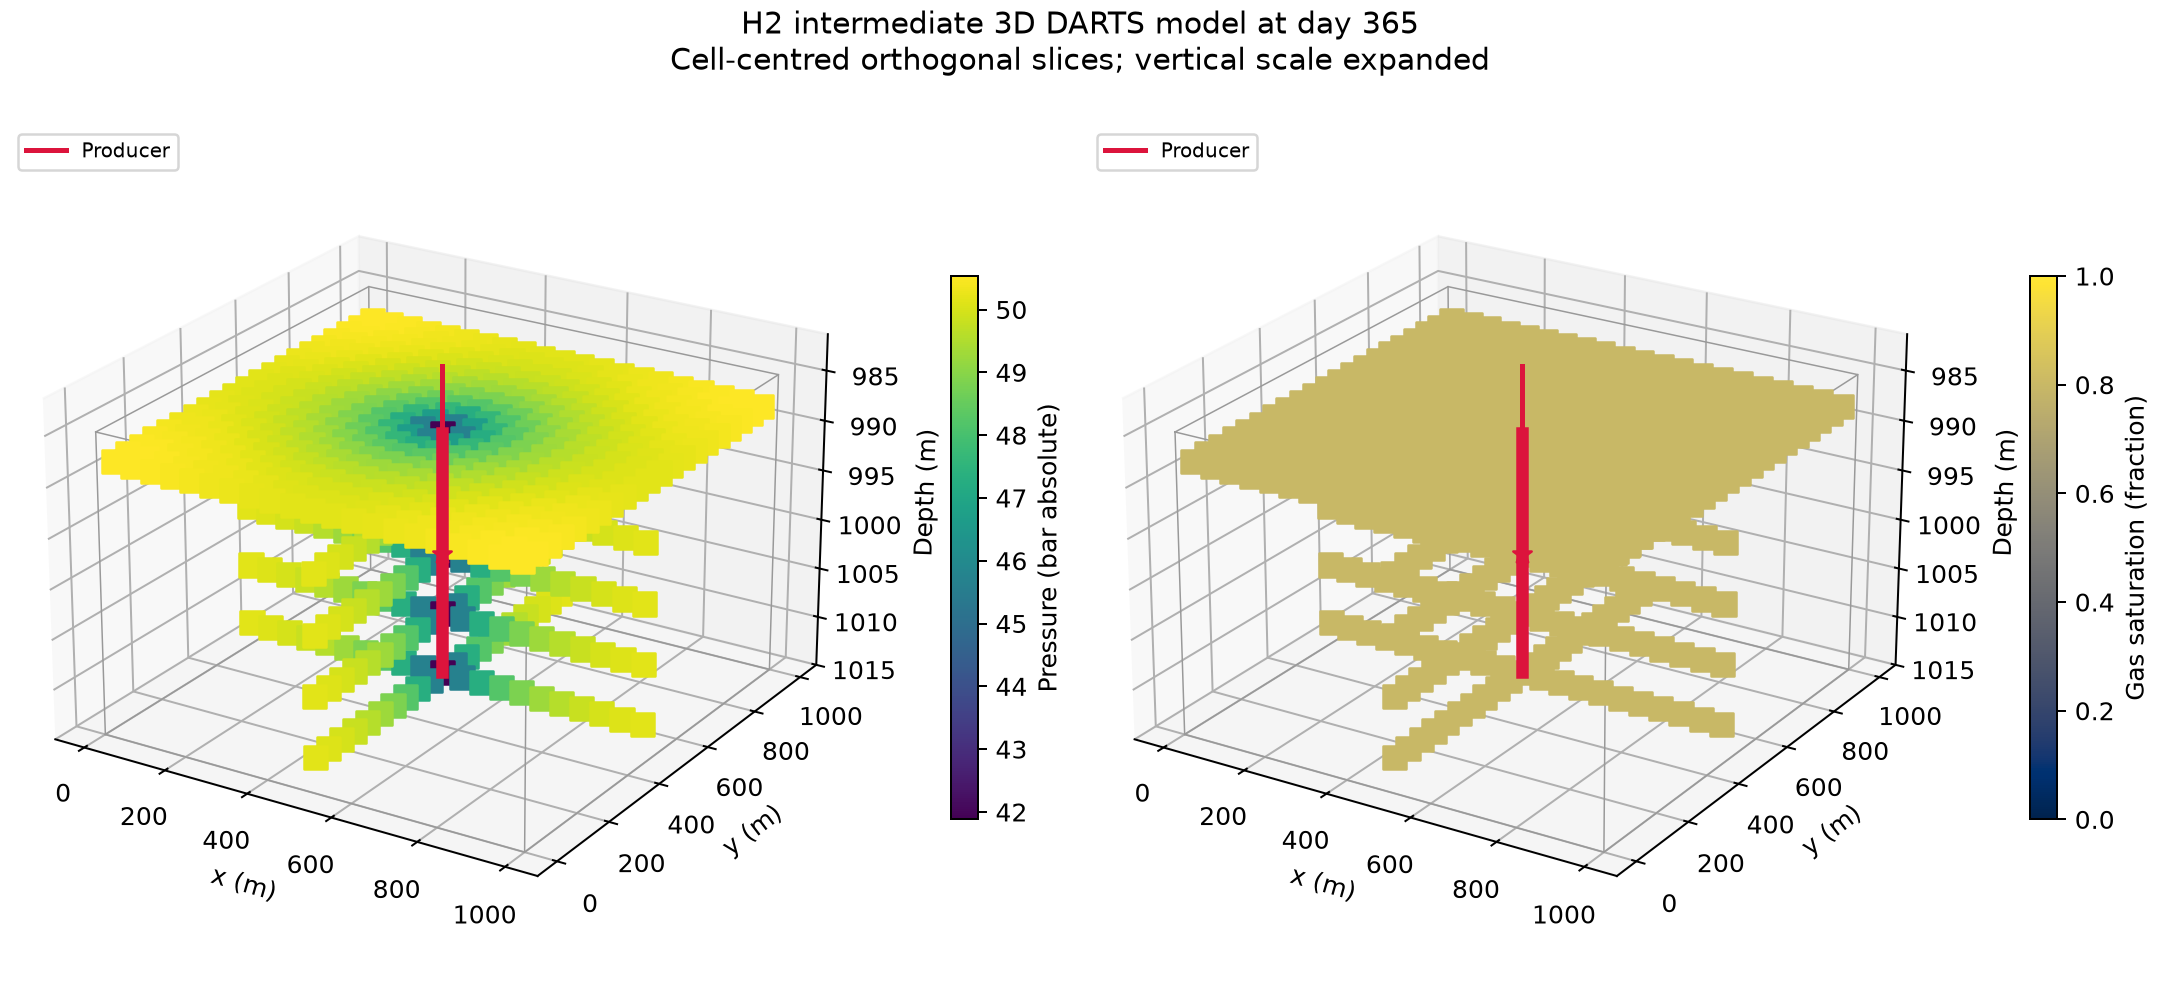

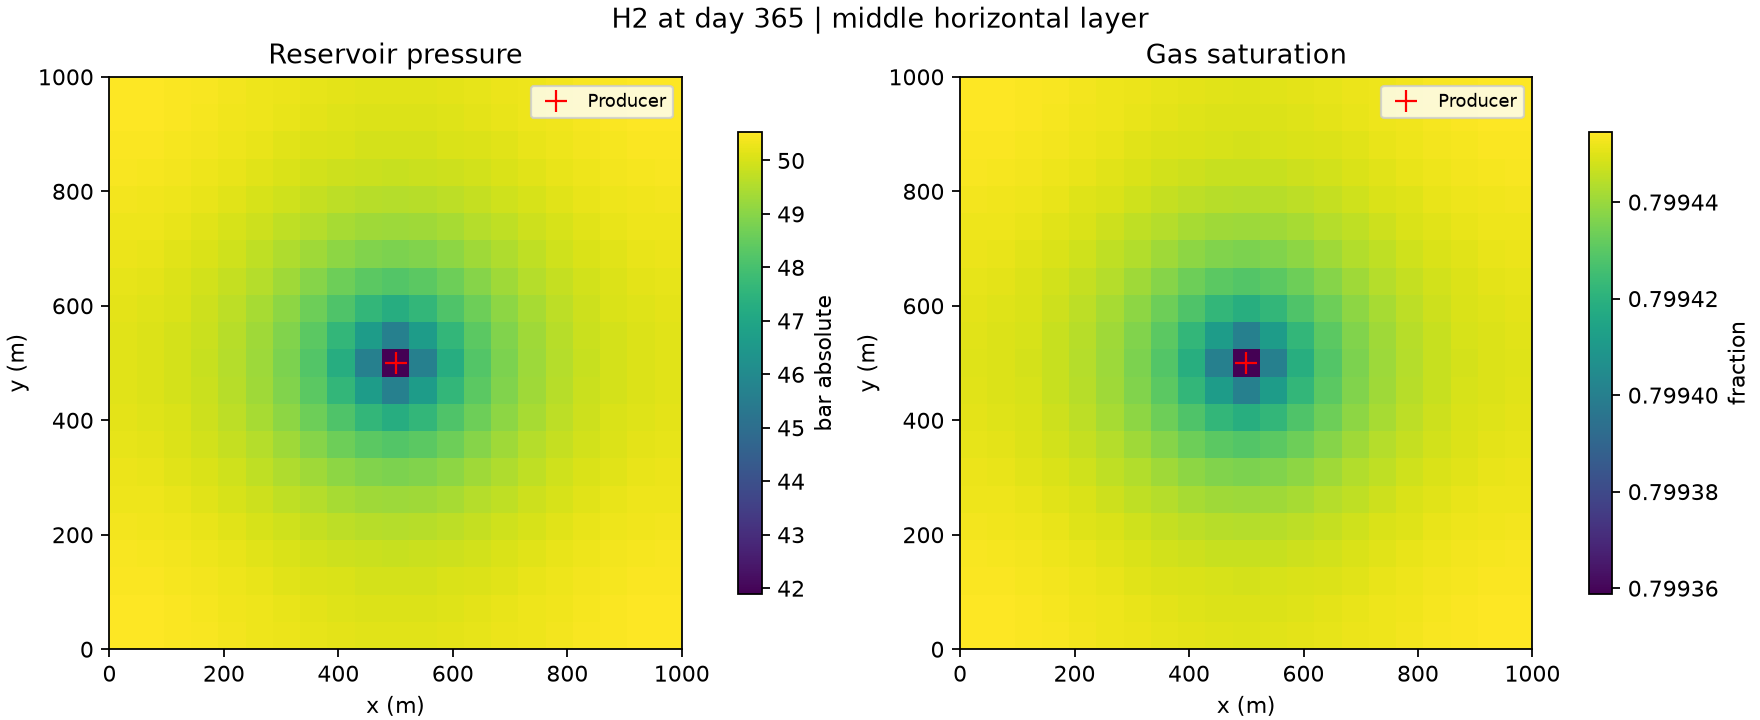

In [5]:
display(Image(filename=str(output / 'hydrogen' / 'reservoir_3d.png')))
display(Image(filename=str(output / 'hydrogen' / 'reservoir_maps.png')))

## Check the calculations

The tests include published density values, a closed reservoir at hydrostatic rest, zero drawdown, known sources and losses, and changes in timestep, interpolation spacing and horizontal and vertical cell size. The material balance uses native accumulation and independently reconstructed well fluxes. Exact fluid-property inventories are also reported.

The model omits dissolution, gas mixing, capillary pressure, diffusion, heat flow and reaction kinetics. The second DARTS model adds a compositional gas–water calculation for a Bourakébougou-inspired scenario. Neither model is calibrated to field production.

In [6]:
verification = json.loads((output / 'validation.json').read_text())
assert verification['passed'], 'Inspect the failed checks before using the results.'
print(f"{sum(verification['checks'].values())} numerical checks passed.")
for name, value in verification['results']['refinement_metrics'].items():
    print(name, value)

17 numerical checks passed.
time_production_relative_difference 0.0009654913361496876
time_mean_pressure_difference_bar 0.04730721798910764
interpolation_production_relative_difference 6.2690375703839085e-06
interpolation_mean_pressure_difference_bar 0.0003413428556413578
grid_production_relative_difference 0.010691414883118389
grid_mean_pressure_difference_bar 0.5179175034901462
vertical_grid_production_relative_difference 4.016584807941003e-05
vertical_grid_mean_pressure_difference_bar 0.001966018464827357
coarse_to_base_production_relative_difference 0.010862560379403068


## Running from the terminal

```bash
./run_darts.sh white_hydrogen/darts/run.py --suite
./run_darts.sh white_hydrogen/darts/validate.py
```

`README.md` gives the units, assumptions and output descriptions. Hydrogen density follows [Lemmon, Huber and Leachman (2008)](https://tsapps.nist.gov/publication/get_pdf.cfm?pub_id=832233). The related research chapter explains the progression from the tank to both DARTS models.